# Sentiment Analysis using NLP & ML

## Objective
To build an end-to-end sentiment analysis system using NLP preprocessing, feature engineering, and machine learning models.

In [2]:
#Import Libraries

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
#Load Dataset(Kaggle)

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 1. Data Understanding

In [4]:
print("Shape:", df.shape)  #shape of dataset

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# check missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nSample Data:")
print(df['review'].iloc[0])

Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing Values:
review       0
sentiment    0
dtype: int64

Sample Data:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christ

### 📊 Data Understanding

The dataset contains 50,000 movie reviews with their corresponding sentiment labels.

- The dataset has 2 columns: 'review' and 'sentiment'.
- The sentiment column consists of two classes: positive and negative.
- The dataset is perfectly balanced with 25,000 positive and 25,000 negative reviews.
- There are no missing values in the dataset, which means the data is clean and complete.

From the sample review, we can observe that:
- The text is long and unstructured.
- It contains HTML tags like <br />.
- It includes punctuation, mixed casing, and special characters.

This indicates that preprocessing is necessary to clean and normalize the text before applying machine learning models.

## 2. NLP Preprocessing

In [6]:
#Import Libraries
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\q\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [7]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # remove HTML tags (important for this dataset)
    text = re.sub(r'<.*?>', '', text)
    
    # remove special characters & punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # stemming
    words = [stemmer.stem(word) for word in words]
    
    # join back to sentence
    return " ".join(words)

In [8]:
df['clean_text'] = df['review'].apply(preprocess_text)

df[['review', 'clean_text']].head()

,review,clean_text
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


### 🧹 NLP Preprocessing

In this step, the raw text data was cleaned and normalized to make it suitable for machine learning models.

The following preprocessing techniques were applied:

- Converted text to lowercase
- Removed URLs and HTML tags
- Removed punctuation and special characters
- Tokenized the text into words
- Removed stopwords to eliminate less meaningful words
- Applied stemming to reduce words to their root form

This preprocessing step helps in reducing noise and improving the quality of features for model training.

## 3. Feature Engineering

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

X_bow = bow.fit_transform(df['clean_text'])

print("BoW Shape:", X_bow.shape)

BoW Shape: (50000, 174608)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df['clean_text'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (50000, 174608)


In [11]:
from sklearn.model_selection import train_test_split

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

### 🔢 Feature Engineering

In this step, the cleaned text data was converted into numerical form so that it can be used by machine learning models.

Two techniques were used:

- Bag of Words (BoW): Converts text into word frequency counts.
- TF-IDF: Assigns importance to words based on their frequency across documents.

TF-IDF was selected for model training because it provides better representation by reducing the impact of commonly occurring words.

This step is crucial as machine learning models require numerical input.

## 4. Model Building

### Step 1: Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

### Step 2: Naive Bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

### Step 3: Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

### 🤖 Model Building

In this step, multiple machine learning models were trained using the TF-IDF features.

The following models were used:

- Logistic Regression: Performs well on text data and handles high-dimensional features efficiently.
- Naive Bayes: A probabilistic model that is fast and effective for NLP tasks.
- Decision Tree: A rule-based model that splits data based on feature values.

Each model was trained on the training dataset and used to predict sentiment on the test dataset.

## 5. Model Evaluation

### Step 1: Create Evaluation Function

In [15]:
#Evaluation function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')
    
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))

### Step 2: Evaluate all models

In [29]:
results = []

def evaluate_model(name, y_test, y_pred):
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))

In [31]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)

evaluate_model("Naive Bayes", y_test, y_pred_nb)

evaluate_model("Decision Tree", y_test, y_pred_dt)


Logistic Regression
Accuracy : 0.889
Precision: 0.8789
Recall   : 0.9043
F1 Score : 0.8914

Naive Bayes
Accuracy : 0.8611
Precision: 0.8711
Recall   : 0.8502
F1 Score : 0.8605

Decision Tree
Accuracy : 0.7123
Precision: 0.7152
Recall   : 0.713
F1 Score : 0.7141


In [32]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8890,0.878881,0.904346,0.891432
1,Naive Bayes,0.8611,0.871086,0.850169,0.860500
2,Decision Tree,0.7123,0.715167,0.713038,0.714101


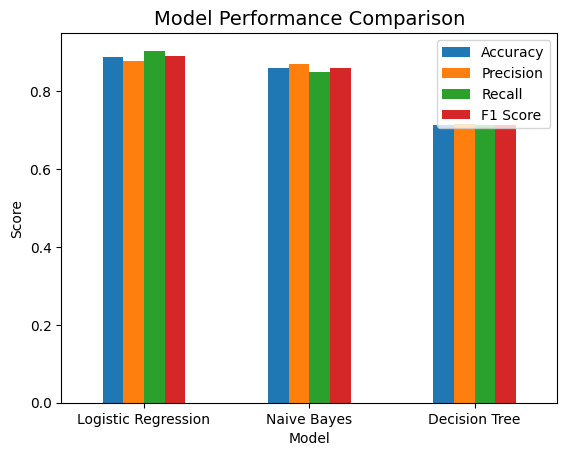

In [34]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar")

plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

### 📊 Model Evaluation

The performance of the models was evaluated using Accuracy, Precision, Recall, and F1 Score.

- Accuracy measures overall correctness of the model.
- Precision indicates how many predicted positive reviews are actually positive.
- Recall shows how many actual positive reviews were correctly identified.
- F1 Score provides a balance between precision and recall.

These metrics help in understanding the strengths and weaknesses of each model.

Overall, TF-IDF with Logistic Regression provided the best results for sentiment classification.

## 6. Comparison & Insights


In this project, different preprocessing techniques, feature engineering methods, and machine learning models were applied to build a sentiment analysis system.

### 🔹 Preprocessing Insights
The preprocessing steps such as lowercasing, removing punctuation, removing stopwords, and applying stemming helped in reducing noise and improving the quality of the text data. Removing HTML tags and special characters was especially important for this dataset.

### 🔹 Vectorization Comparison
Both Bag of Words (BoW) and TF-IDF were used for converting text into numerical form. TF-IDF performed better because it gives importance to meaningful words and reduces the impact of frequently occurring common words.

### 🔹 Model Comparison
- Logistic Regression performed the best among all models due to its ability to handle high-dimensional text data efficiently.
- Naive Bayes was fast and gave decent results but slightly lower accuracy.
- Decision Tree showed lower performance, possibly due to overfitting.

### 🔹 Trade-offs
- Logistic Regression provides better accuracy but takes more time compared to Naive Bayes.
- Naive Bayes is faster but assumes independence between words, which is not always true.
- Decision Trees are easy to interpret but may not perform well on high-dimensional text data.

###  **Final Conclusion**
Overall, TF-IDF combined with Logistic Regression gave the best performance for sentiment analysis.

Hence, this approach provides an effective and reliable solution for real-world text classification tasks.

---